# ECG CRNN — Georgia ECG Dataset

SE-ResNet CNN + BiLSTM + SE attention. Same architecture as `ECG_CRNN/ECG_CRNN_PTB_XL.ipynb`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pickle, pathlib, time
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, roc_auc_score, multilabel_confusion_matrix
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from torch_ecg.models import ECG_CRNN
from torch_ecg.cfg import CFG
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", DEVICE)

DATA_DIR = pathlib.Path("../../GeorgiaECG")
CKPT_DIR = pathlib.Path("checkpoints")
CKPT_DIR.mkdir(exist_ok=True)

NORM_CAP = 4000; BATCH_SIZE = 256; LR = 3e-4; WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 50; PATIENCE = 15; WARMUP = 5; NUM_CLASSES = 4
CLASS_NAMES = ["MI", "STTC", "CD", "HYP"]

/home/dulat-rakhymkul/Documents/Temp/DataMining/myenv/lib/python3.12/site-packages/torch/jit/_script.py:1488: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/home/dulat-rakhymkul/Documents/Temp/DataMining/myenv/lib/python3.12/site-packages/torch_ecg/databases/aux_data/aha.py:15: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option("future.no_silent_downcasting", True)


Device: cuda


## Load Data & Split

In [2]:
with open(DATA_DIR / "X_georgia.pickle", "rb") as f: X_all = pickle.load(f)
with open(DATA_DIR / "y_georgia.pickle", "rb") as f: y_all = pickle.load(f)
print(f"X: {X_all.shape}, y: {y_all.shape}")

rng = np.random.default_rng(SEED)
norm_idx    = np.where(y_all.sum(axis=1) == 0)[0]
disease_idx = np.where(y_all.sum(axis=1) > 0)[0]
if len(norm_idx) > NORM_CAP:
    norm_idx = rng.choice(norm_idx, NORM_CAP, replace=False)
keep_idx = np.concatenate([norm_idx, disease_idx])
rng.shuffle(keep_idx)
X_all, y_all = X_all[keep_idx], y_all[keep_idx]

strat_cols = np.concatenate([y_all, (y_all.sum(1)==0).astype(np.float32)[:,None]], axis=1)
msss1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
tr_val_idx, te_idx = next(msss1.split(X_all, strat_cols))
msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.176, random_state=SEED)
tr_idx, val_idx = next(msss2.split(X_all[tr_val_idx], strat_cols[tr_val_idx]))
tr_idx = tr_val_idx[tr_idx]; val_idx = tr_val_idx[val_idx]

X_train,y_train = X_all[tr_idx], y_all[tr_idx]
X_val,y_val     = X_all[val_idx],y_all[val_idx]
X_test,y_test   = X_all[te_idx], y_all[te_idx]
print(f"Train {len(tr_idx)} | Val {len(val_idx)} | Test {len(te_idx)}")

X: (10344, 12, 1000), y: (10344, 4)
Train 7230 | Val 1559 | Test 1555


## Dataset & DataLoaders

In [3]:
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

_kw = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
tr_loader  = DataLoader(ECGDataset(X_train,y_train), shuffle=True,  **_kw)
val_loader = DataLoader(ECGDataset(X_val,  y_val),   shuffle=False, **_kw)
te_loader  = DataLoader(ECGDataset(X_test, y_test),  shuffle=False, **_kw)

## Model

In [4]:
cnn_cfg = CFG(
    name='resnet_nature_comm_se',
)
rnn_cfg = CFG(
    name='lstm',
    hidden_sizes=[256, 128],
    bias=True,
    dropouts=0.2,
    bidirectional=True,
    return_sequences=False,
)
attn_cfg = CFG(
    name='se',
    dropout=0.2,
    activation='relu',
)
clf_cfg = CFG(
    out_channels=[NUM_CLASSES],
    activation='mish',
    bias=True,
    dropouts=0.0,
)
model_cfg = CFG(cnn=cnn_cfg, rnn=rnn_cfg, attn=attn_cfg, clf=clf_cfg)

model = ECG_CRNN(classes=CLASS_NAMES, n_leads=12, config=model_cfg).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Parameters: 8,500,344


## Loss, Optimizer, Scheduler

In [5]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction="none")
    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        p_t = torch.sigmoid(logits)*targets + (1-torch.sigmoid(logits))*(1-targets)
        return (self.alpha*(1-p_t)**self.gamma * bce_loss).mean()

pos_w = torch.tensor([(y_all.shape[0]-y_all[:,i].sum())/(y_all[:,i].sum()+1e-6) for i in range(NUM_CLASSES)], dtype=torch.float32).to(DEVICE)
criterion = FocalLoss(alpha=0.25, gamma=2.0, pos_weight=pos_w)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)

## Training Loop

In [6]:
def run_epoch(loader, mdl, crit, opt=None):
    training = opt is not None
    mdl.train() if training else mdl.eval()
    total_loss, all_probs, all_tgts = 0., [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = mdl(xb)
            loss = crit(logits, yb)
            if training:
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(mdl.parameters(), 1.0); opt.step()
            total_loss += loss.item()*len(xb)
            all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
            all_tgts.append(yb.detach().cpu().numpy())
    probs = np.concatenate(all_probs); tgts = np.concatenate(all_tgts)
    return total_loss/len(loader.dataset), probs, tgts

def compute_metrics(probs, tgts, thresh=0.5):
    preds = (probs>=thresh).astype(int)
    f1_mac = f1_score(tgts, preds, average="macro", zero_division=0)
    try: auc = roc_auc_score(tgts, probs, average="macro")
    except: auc = float("nan")
    return {"f1_macro": f1_mac, "auc_macro": auc}

In [7]:
train_losses, val_losses, val_f1s = [], [], []
best_val_f1, best_state, best_ep, no_improve = 0., None, 0, 0

for epoch in range(1, MAX_EPOCHS+1):
    t0 = time.time()
    tr_loss, _, _ = run_epoch(tr_loader, model, criterion, optimizer)
    val_loss, val_probs, val_tgts = run_epoch(val_loader, model, criterion)
    val_f1 = compute_metrics(val_probs, val_tgts)["f1_macro"]
    scheduler.step(val_loss)
    train_losses.append(tr_loss); val_losses.append(val_loss); val_f1s.append(val_f1)
    marker = ""
    if epoch > WARMUP and val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_ep = epoch; no_improve = 0; marker = " ✓"
    elif epoch > WARMUP:
        no_improve += 1
    print(f"Ep {epoch:3d} | tr {tr_loss:.4f} | val {val_loss:.4f} | F1 {val_f1:.4f} | {time.time()-t0:.1f}s{marker}")
    if epoch > WARMUP and no_improve >= PATIENCE:
        print("Early stopping."); break

torch.save(best_state, CKPT_DIR/"best_model.pt")
print(f"Best epoch {best_ep}, val F1 {best_val_f1:.4f}")

Ep   1 | tr 0.0639 | val 0.0627 | F1 0.4016 | 1.4s
Ep   2 | tr 0.0599 | val 0.0663 | F1 0.2586 | 0.8s
Ep   3 | tr 0.0541 | val 0.0604 | F1 0.3745 | 0.8s
Ep   4 | tr 0.0509 | val 0.0605 | F1 0.4179 | 0.8s
Ep   5 | tr 0.0478 | val 0.0571 | F1 0.4558 | 0.8s
Ep   6 | tr 0.0463 | val 0.0602 | F1 0.4704 | 0.8s ✓
Ep   7 | tr 0.0442 | val 0.0809 | F1 0.3515 | 0.8s
Ep   8 | tr 0.0431 | val 0.1091 | F1 0.2862 | 0.8s
Ep   9 | tr 0.0421 | val 0.0672 | F1 0.4590 | 0.8s
Ep  10 | tr 0.0405 | val 0.0623 | F1 0.5078 | 0.9s ✓
Ep  11 | tr 0.0390 | val 0.0637 | F1 0.5233 | 0.8s ✓
Ep  12 | tr 0.0380 | val 0.0990 | F1 0.4501 | 0.8s
Ep  13 | tr 0.0367 | val 0.0718 | F1 0.5097 | 0.8s
Ep  14 | tr 0.0361 | val 0.0767 | F1 0.5007 | 0.8s
Ep  15 | tr 0.0357 | val 0.0788 | F1 0.5328 | 0.9s ✓
Ep  16 | tr 0.0347 | val 0.0727 | F1 0.5206 | 0.8s
Ep  17 | tr 0.0346 | val 0.0749 | F1 0.5336 | 0.8s ✓
Ep  18 | tr 0.0335 | val 0.0881 | F1 0.5099 | 0.8s
Ep  19 | tr 0.0331 | val 0.0879 | F1 0.5114 | 0.8s
Ep  20 | tr 0.0327 | 

## Training Curves

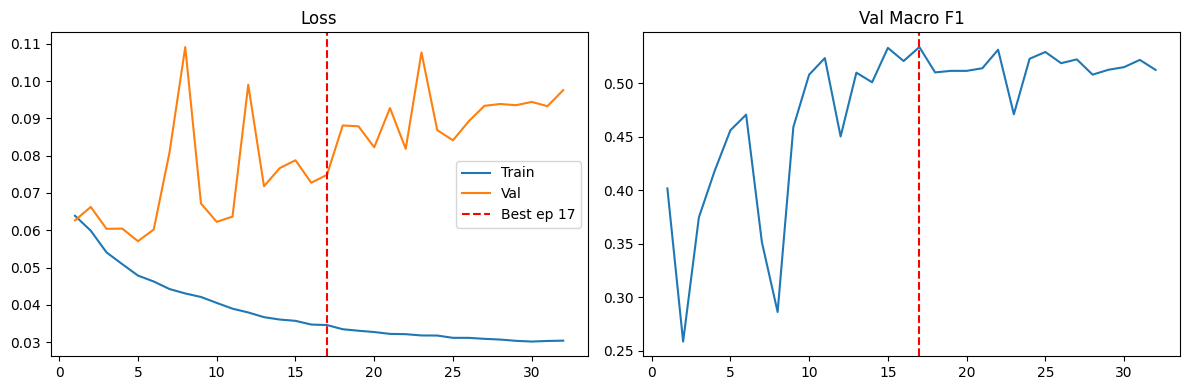

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
eps = range(1, len(train_losses)+1)
ax1.plot(eps, train_losses, label="Train"); ax1.plot(eps, val_losses, label="Val")
ax1.axvline(best_ep, color="r", ls="--", label=f"Best ep {best_ep}"); ax1.legend(); ax1.set_title("Loss")
ax2.plot(eps, val_f1s); ax2.axvline(best_ep, color="r", ls="--"); ax2.set_title("Val Macro F1")
plt.tight_layout(); plt.savefig(CKPT_DIR/"training_curves.png", dpi=100); plt.show()

## Test Evaluation

In [9]:
model.load_state_dict(best_state)
model_trained = model
_, val_probs_tune, val_tgts_tune = run_epoch(val_loader, model_trained, criterion)
_, test_probs, test_tgts         = run_epoch(te_loader,  model_trained, criterion)
cv_test_probs   = val_probs_tune
cv_test_targets = val_tgts_tune

## Threshold Tuning (Val Set — No Leakage)

In [10]:
best_thresholds = []
for i, name in enumerate(CLASS_NAMES):
    best_t, best_f = 0.5, 0.
    for t in np.arange(0.1, 0.9, 0.02):
        f = f1_score(cv_test_targets[:,i], (cv_test_probs[:,i]>=t).astype(int), zero_division=0)
        if f > best_f: best_f=f; best_t=t
    best_thresholds.append(best_t)
    print(f"  {name}: thresh={best_t:.2f}  val_F1={best_f:.4f}")
tuned_arr = np.array(best_thresholds)

  MI: thresh=0.66  val_F1=0.3841
  STTC: thresh=0.46  val_F1=0.6757
  CD: thresh=0.44  val_F1=0.6603
  HYP: thresh=0.44  val_F1=0.5796


In [11]:
preds_def   = (test_probs >= 0.5).astype(int)
preds_tuned = (test_probs >= tuned_arr).astype(int)
print(f"{'Class':<8} {'F1_def':>8} {'F1_tuned':>10}")
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<8} {f1_score(test_tgts[:,i],preds_def[:,i],zero_division=0):8.4f} {f1_score(test_tgts[:,i],preds_tuned[:,i],zero_division=0):10.4f}")
f1d = f1_score(test_tgts, preds_def,   average="macro", zero_division=0)
f1t = f1_score(test_tgts, preds_tuned, average="macro", zero_division=0)
print(f"{'Macro':<8} {f1d:8.4f} {f1t:10.4f}")
try: print(f"AUC: {roc_auc_score(test_tgts, test_probs, average='macro'):.4f}")
except: pass

Class      F1_def   F1_tuned
MI         0.4130     0.4523
STTC       0.6776     0.6677
CD         0.6067     0.6522
HYP        0.5086     0.5828
Macro      0.5515     0.5887
AUC: 0.7694


## Confusion Matrices

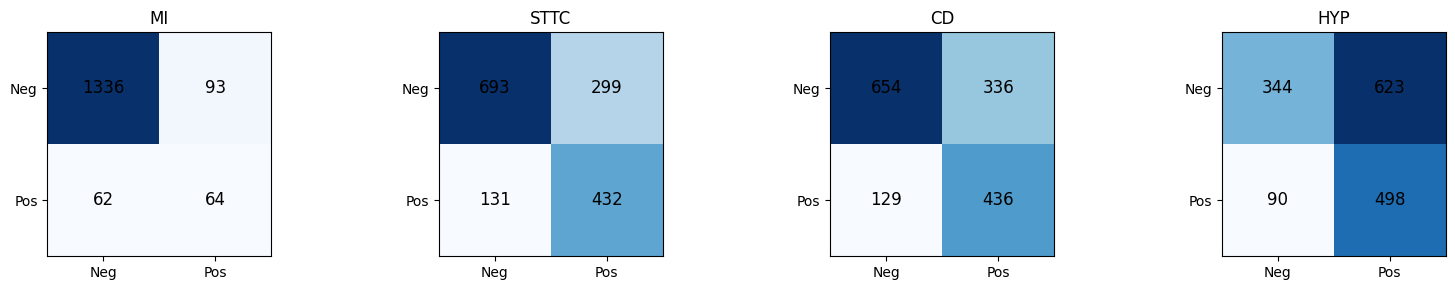

In [12]:
mcm = multilabel_confusion_matrix(test_tgts.astype(int), preds_tuned)
fig, axes = plt.subplots(1,4, figsize=(16,3))
for i,(ax,name) in enumerate(zip(axes,CLASS_NAMES)):
    ax.imshow(mcm[i], cmap="Blues")
    ax.set_title(name); ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Neg","Pos"]); ax.set_yticklabels(["Neg","Pos"])
    for r in range(2):
        for c in range(2): ax.text(c,r,mcm[i][r,c],ha="center",va="center",fontsize=12)
plt.tight_layout(); plt.savefig(CKPT_DIR/"confusion_matrices.png",dpi=100); plt.show()